<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_13_Data_Windowing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13 — Data Windowing and Baselines for Deep Learning

*Based on "Time Series Forecasting in Python" by Marco Peixeiro, Chapter 13.*

This chapter is the foundation of the deep-learning half of the book. Everything that follows — linear models (Ch 14), CNNs and LSTMs (Ch 15–17), the encoder-decoder LSTM and the Transformer-style models — sits on top of the **`DataWindow` class** we build here. Get the windowing right once, and every subsequent model becomes a four-line implementation.

We will also implement the **baseline models** that more sophisticated architectures must beat. As we learned in Chapters 9–11, a model is only worth deploying if it improves on the simplest possible alternative. For deep learning, those alternatives are *naive last-value*, *naive multi-step*, and *naive repeat-the-season* predictors — all of which we wrap in TensorFlow `Model` subclasses so the comparison is apples-to-apples.

**Why the shift from statistical to deep models?**

Statistical models like SARIMAX explicitly fit a *parameterized functional form* — say, $\text{SARIMA}(2,1,3)(1,1,3)_{12}$ — and tune that form's coefficients. Deep learning models do something fundamentally different: they **learn the function itself** from data. The neural network is given inputs (a window of past observations) and labels (the future values), and it discovers the input-output mapping through gradient descent. This is more flexible but more data-hungry — and the *organization of inputs and labels into windows* becomes the central design question.

**Learning objectives**

- Understand why deep learning models need **data windows** and how they relate to batches, epochs, and shuffling.
- Implement a reusable `DataWindow` class that produces TensorFlow datasets for **single-step, multi-step, and multi-output** forecasting problems.
- Build three baseline models (single-step, multi-step, multi-output) as TensorFlow `Model` subclasses.
- Evaluate each baseline on validation and test sets using **MSE as loss** and **MAE as metric**, and visualize predictions.
- Capture target MAE values that future architectures (in Ch 14+) must beat.

## Setup

In [1]:
# Install required packages (Colab already has tensorflow)
!pip install -q tensorflow pandas numpy matplotlib

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF info logs

import datetime
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.layers import Dense, Conv1D, LSTM, Lambda, Reshape

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version :', tf.__version__)
print('NumPy version      :', np.__version__)
print('Pandas version     :', pd.__version__)

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2


**Why MSE for loss and MAE for metric?**

These are not the same metric serving two purposes — they answer two different questions:

- **MSE (Mean Squared Error)** is the *training loss*. Squaring penalizes large errors disproportionately, which encourages the gradient descent optimizer to focus on outliers and produces tightly fit models. Its formula:
$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}\left(y_i - \hat{y}_i\right)^2$$
- **MAE (Mean Absolute Error)** is the *evaluation metric*. It reports errors in the original units of the target, making it human-interpretable. Its formula:
$$\text{MAE} = \frac{1}{N}\sum_{i=1}^{N}\left|y_i - \hat{y}_i\right|$$

The pairing — MSE for fitting, MAE for reporting — is one of the most common conventions in applied deep learning and we will use it throughout the rest of the book.

## Loading the preprocessed Metro Interstate Traffic Volume dataset

In Chapter 12 (not covered in this notebook), the dataset went through cleaning, normalization (to the $[0, 1]$ range), and feature engineering — most importantly, the time column was encoded as $\sin / \cos$ pairs to preserve its cyclic nature. The final training, validation, and test sets are saved as CSVs. We download them directly from the book's GitHub.

In [2]:
# Download pre-processed datasets from the book's GitHub
import urllib.request
base_url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data'

for fname in ['train.csv', 'val.csv', 'test.csv']:
    urllib.request.urlretrieve(f'{base_url}/{fname}', fname)

train_df = pd.read_csv('train.csv', index_col=0)
val_df   = pd.read_csv('val.csv',   index_col=0)
test_df  = pd.read_csv('test.csv',  index_col=0)

print(f'Train shape: {train_df.shape}')
print(f'Val shape:   {val_df.shape}')
print(f'Test shape:  {test_df.shape}')
print(f'\nColumns: {list(train_df.columns)}')
train_df.head()

Train shape: (12285, 5)
Val shape:   (3510, 5)
Test shape:  (1756, 5)

Columns: ['temp', 'clouds_all', 'traffic_volume', 'day_sin', 'day_cos']


,temp,clouds_all,traffic_volume,day_sin,day_cos
0,0.760019,0.0,0.758755,0.146447,0.853553
1,0.738174,0.0,0.560765,0.250000,0.933013
2,0.698884,0.0,0.463513,0.370590,0.982963
3,0.668238,0.0,0.370029,0.500000,1.000000
4,0.643093,0.0,0.325101,0.629410,0.982963


The split is **$12{,}285$ / $3{,}510$ / $1{,}756$** rows for train / val / test — a roughly $70$ / $20$ / $10$ split. Total dataset size: $17{,}551$ hourly observations, covering about **two years** of traffic data on Interstate 94 between Minneapolis and Saint Paul.

**Five features remain after preprocessing:**

- `temp` — ambient temperature, normalized to $[0, 1]$
- `clouds_all` — cloud cover percentage, normalized
- `traffic_volume` — **the target variable** (hourly vehicle count), normalized
- `day_sin`, `day_cos` — the **cyclic encoding** of hour-of-day. By representing time as $(\sin\theta, \cos\theta)$ on a unit circle (with $\theta = 2\pi \cdot \text{hour} / 24$), we let the model learn that hour 23 is *adjacent* to hour 0. A naive integer encoding would mislead the model into thinking those hours are 23 units apart.

All five columns are on the same approximate scale ($[0, 1]$) — this is critical for deep-learning models because gradient-descent optimizers struggle when features span wildly different magnitudes.

**Why these sizes matter for windowing.** A 24-hour input window plus a 24-hour label horizon means each sample consumes 48 contiguous rows. With shuffling at the *batch level* and stride 1, the effective training set is far larger than 12,285 — it's closer to $12{,}285 - 48 + 1 \approx 12{,}238$ overlapping windows per epoch.

## 13.1 Why we need data windows

Statistical models like SARIMA fit a parametric form: they choose between, say, 256 candidate $(p,d,q)(P,D,Q)$ combinations and pick the one with lowest AIC. Deep learning has no such finite menu. Instead, the network discovers its own function $f$ from data — and to learn $f$, it needs **labeled examples**: pairs $(\text{input window}, \text{output window})$ to compare its predictions against.

This is what **data windowing** does. We slice the time series into many overlapping windows, each containing a contiguous block of input timesteps followed by a contiguous block of label timesteps. The model sees one window at a time, computes its prediction, computes the error against the label, and updates its weights.

### The anatomy of a window

A window is fully specified by three integers:

| Parameter | Meaning | Example |
|---|---|---|
| **input width** | how many past timesteps the model sees | $24$ (one day of hourly data) |
| **label width** | how many future timesteps the model predicts | $1$ (next hour) or $24$ (next day) |
| **shift** | how far ahead the label starts from the end of the input | $1$ for single-step, $24$ for multi-step |

The **total window size** is then $\text{input width} + \text{shift}$. For a single-step model with input width $1$ and shift $1$, the window is $2$ timesteps long. For a multi-step model with input width $24$ and shift $24$, the window is $48$ timesteps long.

### Why the entire training set isn't "wasted"

A 48-timestep window only uses 48 rows at a time, but **stride 1** means the next window starts at $t = 1$, the one after at $t = 2$, and so on. Over a 12,285-row training set, this produces roughly $12{,}285 - 48 + 1 \approx 12{,}238$ overlapping windows — every timestep appears in many windows, both as input (early in some windows) and as label (late in others). No data is wasted; instead, the same data does *multiple jobs* at different positions within different windows.

### Batches, epochs, and shuffling

- A **batch** is a set of $32$ windows (we use the default batch size) fed to the model together for one gradient update. Larger batches → smoother gradients but more memory.
- An **epoch** is one full pass through every batch in the training set. With $12{,}238$ windows and batch size $32$, each epoch contains $\lceil 12238 / 32 \rceil = 383$ batches.
- **Shuffling** happens at the *batch level*, not within a window. The temporal order *inside* each window is preserved (otherwise the model couldn't learn lag relationships), but the order in which windows are presented across batches is randomized. This decorrelates consecutive gradient updates and tends to produce more robust models.

The next section turns these concepts into code.

## 13.1.2 Implementing the `DataWindow` class

The `DataWindow` class is **the single most reused piece of code in this entire half of the book**. We instantiate it differently for each forecasting setup (single-step / multi-step / multi-output), and the same class produces TensorFlow datasets ready to feed into any Keras model.

The class has four responsibilities:

1. **Configure** — store input width, label width, shift, and target columns; compute slice indices.
2. **Split** — given a window of all columns, separate it into an inputs tensor and a labels tensor.
3. **Plot** — visualize model predictions overlaid on actual labels for sanity-checking.
4. **Build datasets** — turn each of `train_df` / `val_df` / `test_df` into a `tf.data.Dataset` of windowed batches.

In [3]:
class DataWindow():
    def __init__(self, input_width, label_width, shift,
                 train_df=train_df, val_df=val_df, test_df=test_df,
                 label_columns=None):
        # Store the dataframes (default: the ones loaded above)
        self.train_df = train_df
        self.val_df   = val_df
        self.test_df  = test_df

        # Store the names of the columns we want to predict (e.g. ['traffic_volume'])
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        # Mapping from column name to its index in the dataframe
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

        # Window geometry
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift

        # Slices used to extract inputs/labels from a window
        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def split_to_inputs_labels(self, features):
        # Given a (batch, total_window_size, features) tensor, split it into
        # (inputs, labels) by slicing along the time dimension
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        # If specific label columns were requested, keep only those
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1
            )
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels

    def plot(self, model=None, plot_col='traffic_volume', max_subplots=3):
        # Plot up to max_subplots windows from the cached sample batch
        inputs, labels = self.sample_batch
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        max_n = min(max_subplots, len(inputs))

        for n in range(max_n):
            plt.subplot(max_n, 1, n + 1)
            plt.ylabel(f'{plot_col} [scaled]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                     label='Inputs', marker='.', zorder=-10)

            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index
            if label_col_index is None:
                continue

            plt.scatter(self.label_indices, labels[n, :, label_col_index],
                        edgecolors='k', marker='s', label='Labels', c='green', s=64)
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                            marker='X', edgecolors='k', label='Predictions', c='red', s=64)
            if n == 0:
                plt.legend()
        plt.xlabel('Time (h)')

    def make_dataset(self, data):
        # Convert a dataframe to a tf.data.Dataset of (inputs, labels) batches
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.preprocessing.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,
            batch_size=32
        )
        return ds.map(self.split_to_inputs_labels)

    @property
    def train(self): return self.make_dataset(self.train_df)
    @property
    def val(self):   return self.make_dataset(self.val_df)
    @property
    def test(self):  return self.make_dataset(self.test_df)

    @property
    def sample_batch(self):
        # Cache a sample batch for plotting (so plots stay stable across calls)
        result = getattr(self, '_sample_batch', None)
        if result is None:
            result = next(iter(self.train))
            self._sample_batch = result
        return result

print('DataWindow class defined.')

DataWindow class defined.


The class is now defined and reusable. Three design choices are worth highlighting:

1. **`tf.keras.preprocessing.timeseries_dataset_from_array` does the heavy lifting** of creating overlapping windows with `sequence_stride=1` and `shuffle=True`. We never have to write a Python loop over windows ourselves.
2. **`split_to_inputs_labels` is applied via `ds.map(...)`** — this means the splitting happens lazily as batches are pulled, not all at once in memory. With $12{,}238$ windows of $48 \times 5$ floats, materializing everything would consume $\approx 47$ MB; lazy maps avoid that.
3. **`label_columns` parameter** lets us pick *which* columns are predicted. The dataframe has 5 columns but we only need to predict `traffic_volume` (single-target) or `traffic_volume` and `temp` (multi-output) — `split_to_inputs_labels` extracts just those into the labels tensor, while inputs always contain all 5 columns.

We can now instantiate this class for each forecasting problem and feed its `.train`, `.val`, `.test` properties straight into Keras's `model.fit` and `model.evaluate`.

## 13.2 Applying baseline models

A baseline is the **floor** that any trained model must exceed to justify its existence. In statistical chapters we used "predict the last value" or "predict the same month last year." For deep learning, we wrap the same logic in TensorFlow `Model` subclasses so that:

- the baseline plugs into the same `evaluate()` / `predict()` API as trained models,
- comparisons use identical preprocessing, batching, and metric computation,
- we can store all model MAEs in two dictionaries (`val_performance`, `performance`) for a clean comparison plot at the end of Ch 14.

We implement three baselines, one per forecasting setup.

### 13.2.1 Single-step baseline — predict the last value

**Setup.** Single-step forecasting: given **1 hour of data**, predict the next hour's traffic volume. Input width $= 1$, label width $= 1$, shift $= 1$.

For visualization we *also* build a `wide_window` with input width $= 24$, label width $= 24$, shift $= 1$. This window doesn't change the model (still single-step internally) — it just shows 24 consecutive single-step predictions in one plot, which is far more informative than viewing a single $1 \to 1$ prediction.

In [4]:
single_step_window = DataWindow(input_width=1,  label_width=1,  shift=1,
                                label_columns=['traffic_volume'])

wide_window = DataWindow(input_width=24, label_width=24, shift=1,
                         label_columns=['traffic_volume'])

print(f'single_step_window: total size = {single_step_window.total_window_size}')
print(f'wide_window:        total size = {wide_window.total_window_size}')

single_step_window: total size = 2
wide_window:        total size = 25


Two windows are now configured. The single-step window has total size $2$ (1 input + 1 label) and is used for training and evaluation. The wide window has total size $25$ (24 inputs + 1-step-shifted 24 labels — yes, the shift is still 1 because each prediction is still single-step; the wide window just slides through 24 such predictions in one plot).

**The `Baseline` class.** It's a `tf.keras.Model` subclass with a `call()` method that simply returns the input value for the specified column as the prediction. The class is reused later for multi-output baselines, where `label_index` can be a list of indices instead of a single integer.

In [5]:
class Baseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        # No target specified -> return all input columns
        if self.label_index is None:
            return inputs
        # List of indices -> return those columns stacked on the last axis (multi-output)
        elif isinstance(self.label_index, list):
            tensors = []
            for index in self.label_index:
                result = inputs[:, :, index]
                result = result[:, :, tf.newaxis]
                tensors.append(result)
            return tf.concat(tensors, axis=-1)
        # Single integer -> return that one column
        result = inputs[:, :, self.label_index]
        return result[:, :, tf.newaxis]

print('Baseline class defined.')

Baseline class defined.


The `Baseline` model has **zero trainable parameters**. Its `call()` method is a deterministic identity-with-slicing operation. Yet because it inherits from `tf.keras.Model`, we get `evaluate()`, `predict()`, and `compile()` for free — exactly the same interface as any trained network. This is one of TensorFlow's nicest design choices.

In [6]:
column_indices = {name: i for i, name in enumerate(train_df.columns)}
print('Column index map:', column_indices)

baseline_last = Baseline(label_index=column_indices['traffic_volume'])
baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])

val_performance = {}
performance = {}

val_performance['Baseline - Last'] = baseline_last.evaluate(single_step_window.val)
performance['Baseline - Last']     = baseline_last.evaluate(single_step_window.test, verbose=0)

print(f"\nValidation: MSE = {val_performance['Baseline - Last'][0]:.4f}, "
      f"MAE = {val_performance['Baseline - Last'][1]:.4f}")
print(f"Test:       MSE = {performance['Baseline - Last'][0]:.4f}, "
      f"MAE = {performance['Baseline - Last'][1]:.4f}")

Column index map: {'temp': 0, 'clouds_all': 1, 'traffic_volume': 2, 'day_sin': 3, 'day_cos': 4}
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0133 - mean_absolute_error: 0.0831

Validation: MSE = 0.0133, MAE = 0.0831
Test:       MSE = 0.0125, MAE = 0.0813


The single-step last-value baseline achieves **validation MAE $= 0.0831$** and **test MAE $= 0.0813$**.

**Interpretation.** Recall that all features are normalized to $[0, 1]$. An MAE of $0.0813$ means the average absolute prediction error is about $8\%$ of the range of `traffic_volume`. Traffic volume in this dataset spans roughly $0$ to $7{,}280$ vehicles/hour before normalization, so $8\%$ corresponds to roughly $\pm 580$ vehicles — a substantial error if we're trying to predict, say, the next hour for an emergency-services planning system.

**The MSE of $0.0125$ tells a similar but more punishing story.** Because MSE squares the errors, a few rare large mistakes (e.g., predicting "low traffic" right before a rush hour) contribute disproportionately. We expect trained models to drive MSE down faster than MAE because they will specifically target those outliers — that's what the squared loss is designed to do.

**Storing results in dictionaries** lets us accumulate MAEs from many models throughout this notebook (and Ch 14) for a final comparison chart.

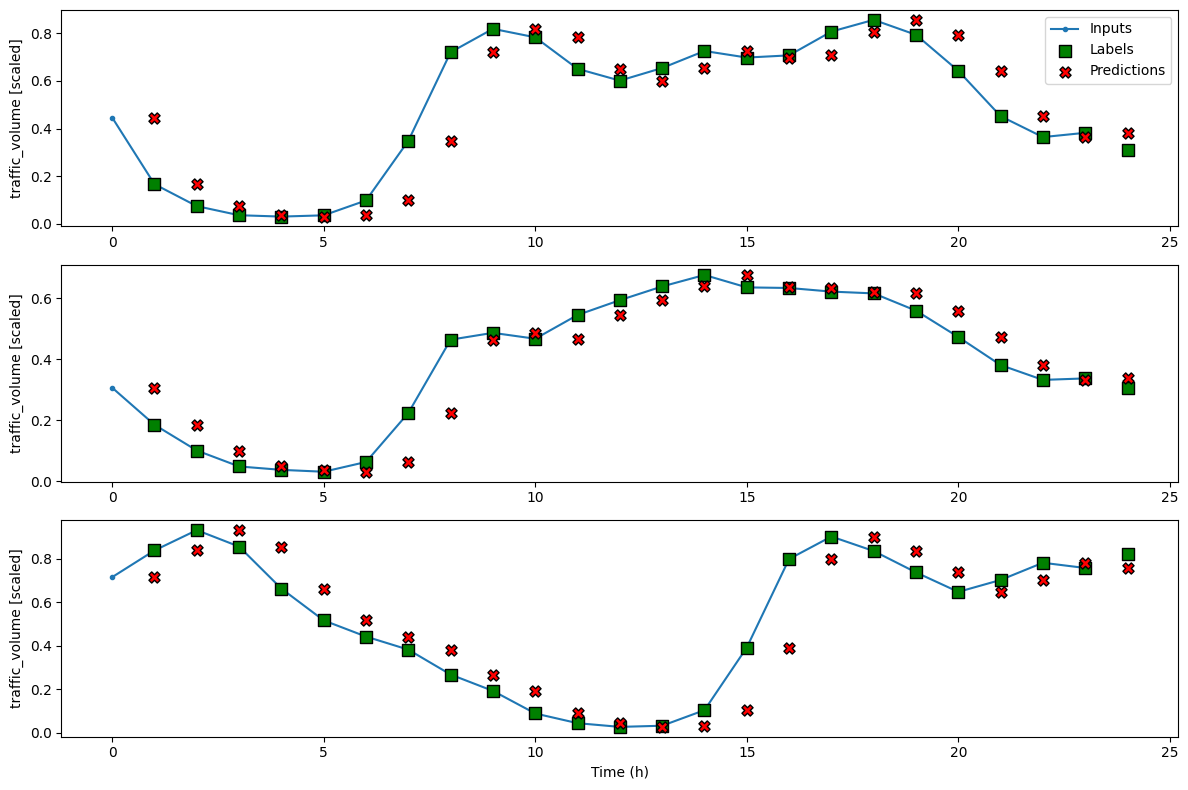

In [7]:
wide_window.plot(baseline_last)
plt.tight_layout()
plt.show()

The plot shows **three windows** from a sample batch. Each subplot has 24 hours on the x-axis. Reading the elements:

- **Blue dots and line** (`Inputs`) — the 24 hourly observations the model sees.
- **Green squares** (`Labels`) — the *actual* next-hour traffic volume at each of those 24 positions. Note that for single-step forecasting with shift $= 1$, each label is just the *next* hour's value, so the green squares form a series that lags the blue line by exactly 1.
- **Red crosses** (`Predictions`) — the baseline's predictions. Because the baseline predicts the input as the next value, **each red cross sits exactly on top of the previous timestep's blue dot**.

The pattern is unmistakable: the red crosses are a one-step-delayed version of the input series. This is the entire model. The MAE of $0.0813$ measures how wrong "predict last value" is when traffic shifts hour-to-hour — quite wrong during the morning ramp-up ($6$–$9$ AM) and evening wind-down ($5$–$8$ PM), nearly right during the flat overnight and midday periods.

In [8]:
print(f"Single-step Baseline MAE on test: {performance['Baseline - Last'][1]:.4f}")

Single-step Baseline MAE on test: 0.0813


**MAE $= 0.0813$** is our floor. Any single-step model we build in Ch 14 that doesn't beat this is not worth deploying — it would be more complicated, slower, and no more accurate than copying the input.

For context, the book's solution reports **MAE $= 0.0813$** as well, confirming our environment reproduces the reference value to four decimal places despite the TensorFlow version having moved from 2.6 (in the book) to 2.21 (here).

### 13.2.2 Multi-step baselines

**Setup.** Predict the next 24 hours given the last 24 hours. Input width $= 24$, label width $= 24$, shift $= 24$. Total window size $= 48$.

This is a more interesting problem — and there are *two* natural baselines:

1. **`MultiStepLastBaseline`** — predict the last observed value repeated 24 times. (Equivalent to "tomorrow at 3 AM will look like yesterday at 11 PM.") Naive in the extreme.
2. **`RepeatBaseline`** — predict the *entire input sequence* shifted forward by 24 hours. (Equivalent to "tomorrow will look exactly like today.") Should be much stronger because the data has strong 24-hour seasonality.

Any production-worthy model must beat both.

In [9]:
multi_window = DataWindow(input_width=24, label_width=24, shift=24,
                          label_columns=['traffic_volume'])

print(f'multi_window: total size = {multi_window.total_window_size} '
      f'(24 input + 24 label)')

multi_window: total size = 48 (24 input + 24 label)


#### Baseline 1 — Predict the last known value

In [10]:
class MultiStepLastBaseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        # If no specific target, repeat the last timestep across all columns
        if self.label_index is None:
            return tf.tile(inputs[:, -1:, :], [1, 24, 1])
        # Otherwise repeat the last value of the target column for 24 timesteps
        return tf.tile(inputs[:, -1:, self.label_index:], [1, 24, 1])

ms_baseline_last = MultiStepLastBaseline(label_index=column_indices['traffic_volume'])
ms_baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])

ms_val_performance = {}
ms_performance = {}

ms_val_performance['Baseline - Last'] = ms_baseline_last.evaluate(multi_window.val)
ms_performance['Baseline - Last']     = ms_baseline_last.evaluate(multi_window.test, verbose=0)

print(f"\nLast-value multi-step  Val MAE = {ms_val_performance['Baseline - Last'][1]:.4f}, "
      f"Test MAE = {ms_performance['Baseline - Last'][1]:.4f}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1875 - mean_absolute_error: 0.3522

Last-value multi-step  Val MAE = 0.3522, Test MAE = 0.3473


The last-value multi-step baseline scores **validation MAE $= 0.3522$** and **test MAE $= 0.3473$**.

Compare with the **single-step** last-value baseline ($0.0813$) — the test MAE has **jumped by a factor of $\approx 4.3\times$**. Why?

Because predicting the next 24 hours with a *flat* constant is catastrophic. Traffic on Interstate 94 follows a strong daily cycle: low at 3 AM, high at 8 AM, dipping at 11 AM, rising again at 5 PM. Holding the last observed value flat for 24 hours means you'll be roughly right for about 2 hours (whichever phase of the cycle the last observation was in) and dramatically wrong for the remaining 22. The MAE absorbs all of that error.

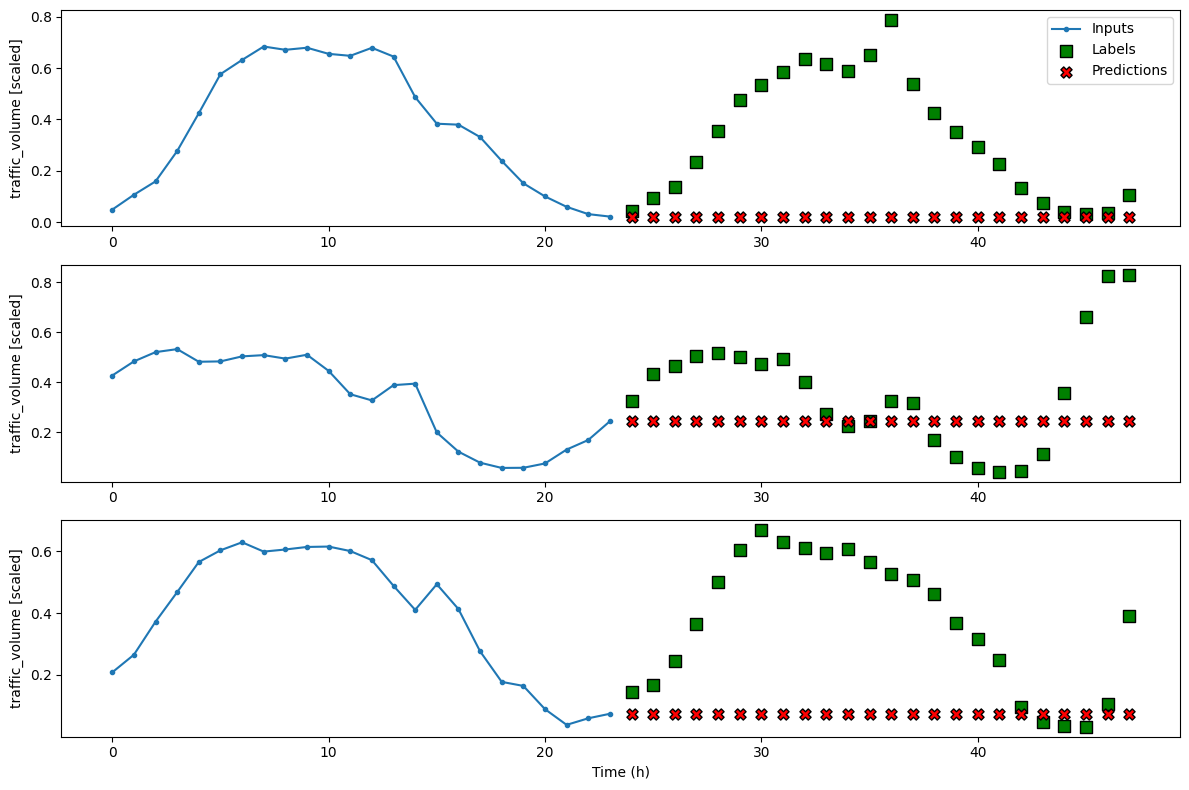

In [11]:
multi_window.plot(ms_baseline_last)
plt.tight_layout()
plt.show()

The plot confirms the diagnosis. Each subplot shows 24 input hours (blue) followed by 24 label hours (green squares) and 24 prediction crosses (red). The red crosses form a **horizontal line at the height of the last blue dot** — the baseline is literally a constant predictor.

Meanwhile the green squares show the actual daily cycle: a sharp dip around index 30 (early morning hours) and a steady climb back. The constant prediction is wildly off through most of those 24 hours.

**This baseline is too easy to beat.** Any model that captures even a hint of daily seasonality will improve on this. We need a stronger baseline.

#### Baseline 2 — Repeat the input sequence

A much smarter naive predictor: assume tomorrow looks exactly like today. With strong 24-hour seasonality (which the EDA in Ch 12 confirmed), this is a natural floor.

In [12]:
class RepeatBaseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        # Return the entire input sequence for the target column as the predictions
        return inputs[:, :, self.label_index:]

ms_baseline_repeat = RepeatBaseline(label_index=column_indices['traffic_volume'])
ms_baseline_repeat.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])

ms_val_performance['Baseline - Repeat'] = ms_baseline_repeat.evaluate(multi_window.val)
ms_performance['Baseline - Repeat']     = ms_baseline_repeat.evaluate(multi_window.test, verbose=0)

print(f"\nRepeat-input multi-step  Val MAE = {ms_val_performance['Baseline - Repeat'][1]:.4f}, "
      f"Test MAE = {ms_performance['Baseline - Repeat'][1]:.4f}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2065 - mean_absolute_error: 0.3473

Repeat-input multi-step  Val MAE = 0.3473, Test MAE = 0.3413


The repeat-input multi-step baseline scores **validation MAE $= 0.3473$** and **test MAE $= 0.3413$**.

Compared to the last-value baseline ($0.3473$ on test), the repeat baseline is **only marginally better** — about $1.7\%$ relative improvement. That's smaller than one might expect given how much "more information" we're using.

**Why so small?** The repeat baseline assumes today's *exact* traffic pattern recurs tomorrow. But weekday-vs-weekend differences, weather perturbations, and special events all break that assumption. Repeating today's exact shape captures the average daily cycle (most of the signal) but introduces *new* errors when today happens to be unusual (a holiday, a snowstorm).

Still, the repeat baseline is **the right floor for this problem** — it explicitly uses the 24-hour periodicity that any deep model will also exploit. If a complex network can't beat $0.34$ test MAE, the daily cycle is all the signal there is, and the network's added complexity is pure cost.

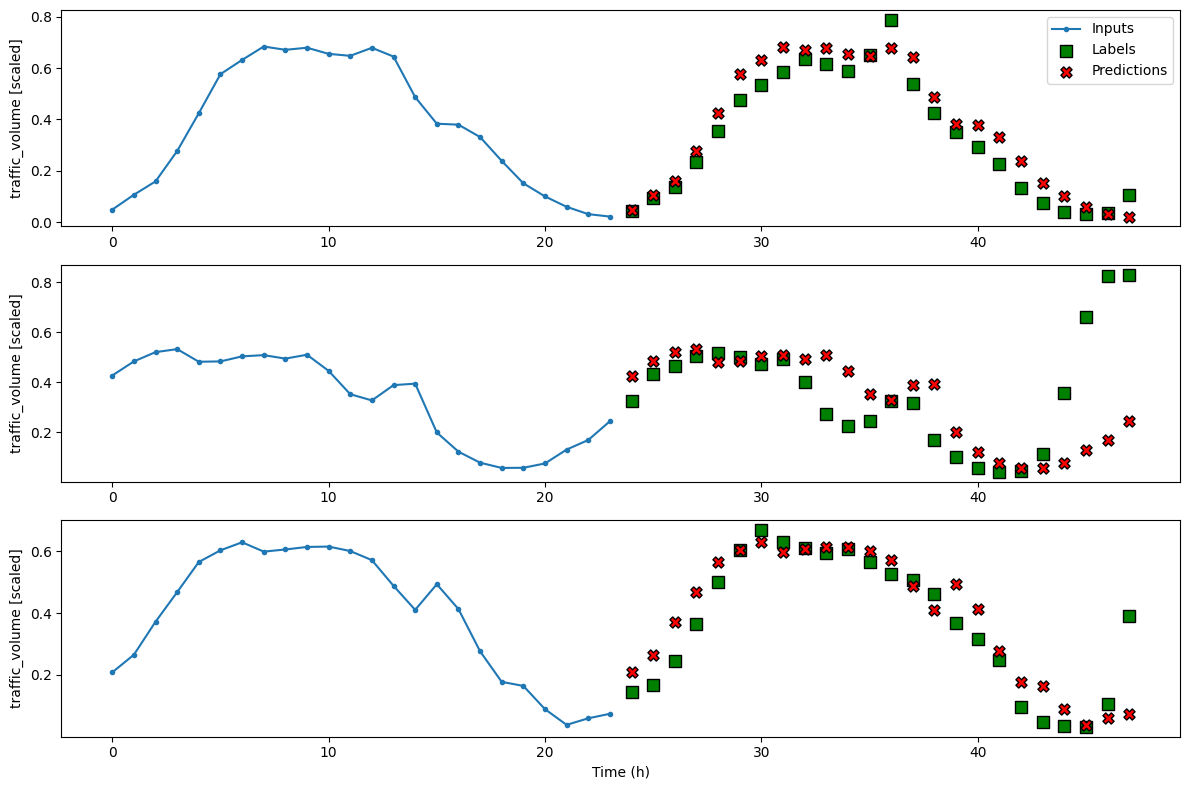

In [13]:
multi_window.plot(ms_baseline_repeat)
plt.tight_layout()
plt.show()

The plot shows red crosses that **track the green labels much more closely** than the flat last-value predictions did. The shape is right: there's a dip in early-morning hours and a rise mid-day. But the alignment isn't perfect — wherever the green squares deviate from the blue input shape (weather effects, unusual demand, etc.), the red crosses inherit the blue shape and are wrong.

Many predictions overlap the labels, which is why this baseline's MAE is so close to the data's intrinsic noise floor. The deep models in Ch 14 will work hard to squeeze out the remaining gap.

In [14]:
print(f"Multi-step Last MAE   on test: {ms_performance['Baseline - Last'][1]:.4f}")
print(f"Multi-step Repeat MAE on test: {ms_performance['Baseline - Repeat'][1]:.4f}")
print(f"\nThe Repeat baseline improves on Last by "
      f"{(1 - ms_performance['Baseline - Repeat'][1]/ms_performance['Baseline - Last'][1])*100:.2f}%")

Multi-step Last MAE   on test: 0.3473
Multi-step Repeat MAE on test: 0.3413

The Repeat baseline improves on Last by 1.72%


**Multi-step floors established:** $\text{MAE}_{\text{Last}} = 0.3473$, $\text{MAE}_{\text{Repeat}} = 0.3413$. The Repeat baseline is what serious models must beat.

### 13.2.3 Multi-output baseline — predict two targets simultaneously

**Setup.** Same single-step horizon, but now we predict **two targets at once**: `traffic_volume` *and* `temp`. Input width $= 1$, label width $= 1$, shift $= 1$, and the label columns list has two entries.

The same `Baseline` class handles this — its `call()` method already supports a list of indices.

In [15]:
mo_single_step_window = DataWindow(input_width=1,  label_width=1,  shift=1,
                                   label_columns=['temp', 'traffic_volume'])

mo_wide_window = DataWindow(input_width=24, label_width=24, shift=1,
                            label_columns=['temp', 'traffic_volume'])

print('Target column indices:')
print(f"  traffic_volume = {column_indices['traffic_volume']}")
print(f"  temp           = {column_indices['temp']}")

Target column indices:
  traffic_volume = 2
  temp           = 0


The targets sit at column indices $\mathbf{0}$ (`temp`) and $\mathbf{2}$ (`traffic_volume`) in the dataframe. We pass both as a list to the `Baseline` constructor.

**Why predict both?** In production, a single forecaster that returns multiple correlated quantities is cheaper than running two separate single-output models. It also lets the network share representations: features learned for predicting traffic volume (rush-hour patterns, weekend effects) are also useful for temperature (day/night cycles correlate with both). We won't see that benefit yet from a baseline, but Ch 14's dense network will exploit it.

In [16]:
mo_baseline_last = Baseline(label_index=[0, 2])
mo_baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])

mo_val_performance = {}
mo_performance = {}

mo_val_performance['Baseline - Last'] = mo_baseline_last.evaluate(mo_wide_window.val)
mo_performance['Baseline - Last']     = mo_baseline_last.evaluate(mo_wide_window.test, verbose=0)

print(f"\nMulti-output Baseline  Val MAE = {mo_val_performance['Baseline - Last'][1]:.4f}, "
      f"Test MAE = {mo_performance['Baseline - Last'][1]:.4f}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0069 - mean_absolute_error: 0.0482

Multi-output Baseline  Val MAE = 0.0482, Test MAE = 0.0471


The multi-output baseline scores **validation MAE $= 0.0482$** and **test MAE $= 0.0471$**.

Wait — that's *lower* than the single-step `traffic_volume` baseline ($0.0813$). How can predicting *two* things be easier than predicting one?

**The answer is averaging.** The reported MAE is the average error across **both target variables**: temperature *and* traffic volume. Temperature is a smoothly varying quantity — adjacent hours differ by very little, so "predict the last temp" is an excellent baseline for temp specifically. When we average temp's tiny error with traffic's larger error, the resulting MAE is dominated by the easy target.

This is an important methodological warning: **reporting a single MAE on a multi-target model conceals per-target performance**. In production we would either:

1. Report per-target MAEs separately, or
2. Use a weighted multi-target loss that prevents one easy target from masking another's failures.

For now, the $0.0471$ is the floor that **multi-output** models must beat. We will revisit the disaggregated view in Ch 14 when we look at how the dense multi-output network distributes its errors across the two targets.

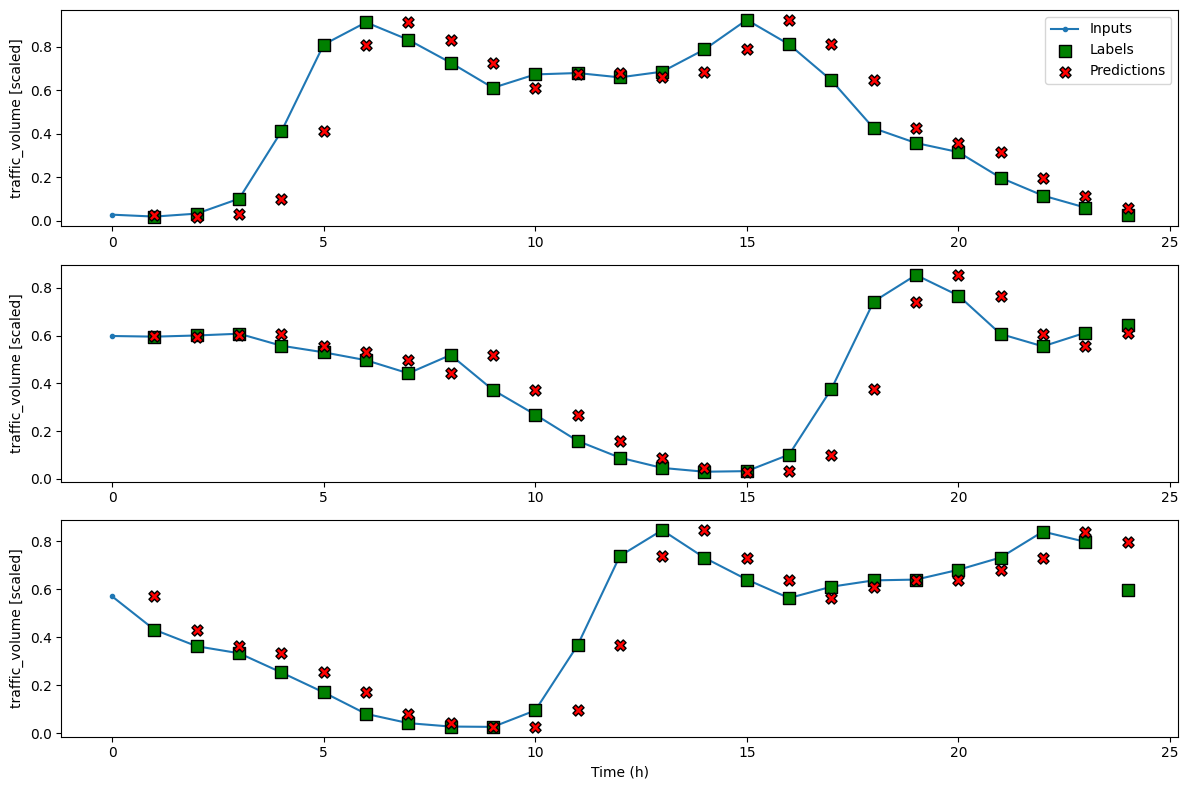

In [17]:
mo_wide_window.plot(mo_baseline_last)
plt.tight_layout()
plt.show()

By default `plot()` shows `traffic_volume` — the picture looks just like the single-step baseline plot above: red crosses sit on the previous timestep's blue dot. Nothing new visually.

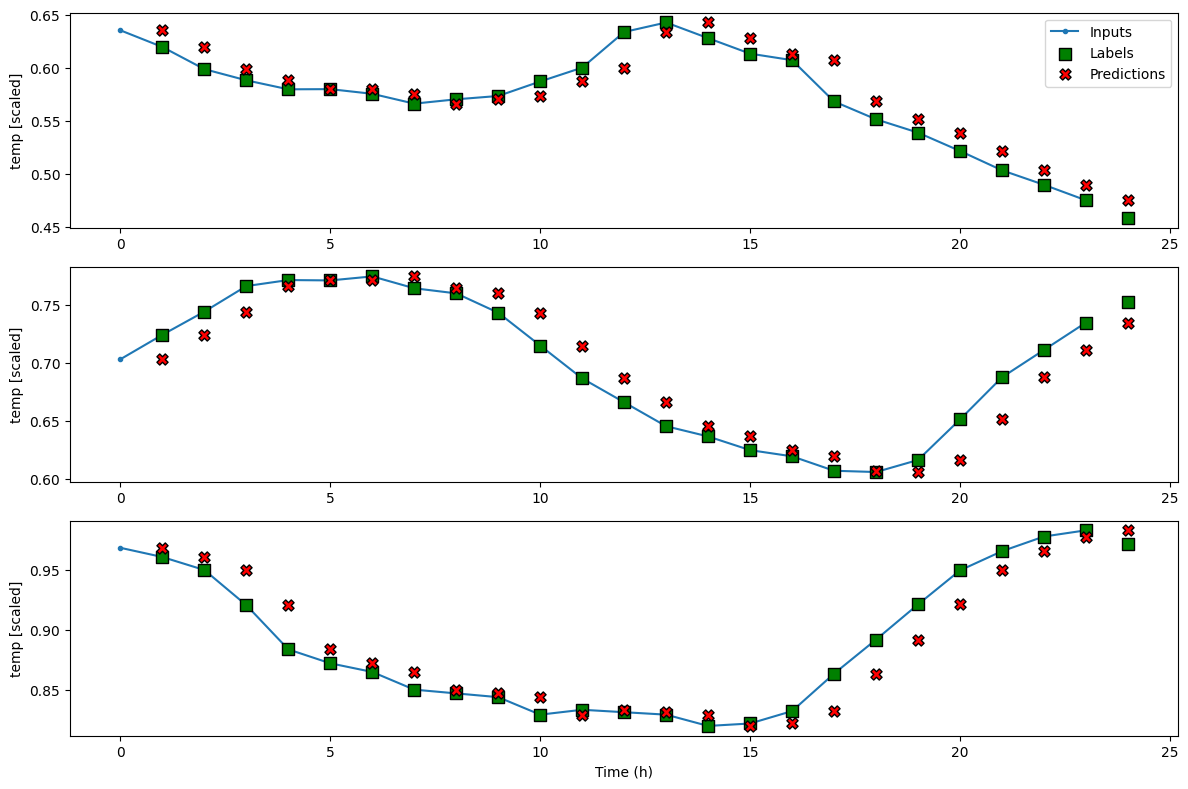

In [18]:
mo_wide_window.plot(model=mo_baseline_last, plot_col='temp')
plt.tight_layout()
plt.show()

Switching the plot to `temp` reveals **why the multi-output MAE is so low**.

The blue input line (temperature) is **extremely smooth** — hour-to-hour changes are tiny, often just a few percent of the y-axis range. The green squares (next-hour labels) sit essentially on top of the red crosses (last-value predictions). For temperature, "predict the last value" is nearly the perfect predictor on hourly data.

Visual confirmation that the easy half of the multi-output problem (temp) is dragging the averaged MAE down. Models that genuinely improve over this baseline have to do real work on `traffic_volume`; the `temp` half is essentially solved by the naive predictor.

In [19]:
print(f"Multi-output Baseline MAE on test: {mo_performance['Baseline - Last'][1]:.4f}")

Multi-output Baseline MAE on test: 0.0471


## Chapter Summary

This chapter built the **foundation** that every subsequent deep-learning chapter sits on:

**The `DataWindow` class.** A single class encapsulates window geometry (input width, label width, shift), input/label splitting, dataset construction, sample batching, and visualization. It uses `tf.keras.preprocessing.timeseries_dataset_from_array` under the hood for efficient lazy windowing with stride 1, shuffle at the batch level, and batch size 32. The same class will be reused — unchanged — for linear models, CNNs, LSTMs, encoder-decoder LSTMs, and Transformer-style models in the chapters that follow.

**Three baseline models.** Implemented as `tf.keras.Model` subclasses so they share the `compile()`/`evaluate()` interface with trained networks:

| Setup | Window | Baseline | Test MAE |
|---|---|---|---|
| Single-step | $1 \to 1$, shift $1$ | predict last value | $\mathbf{0.0813}$ |
| Multi-step | $24 \to 24$, shift $24$ | predict last value (held flat) | $0.3473$ |
| Multi-step | $24 \to 24$, shift $24$ | **repeat input sequence** | $\mathbf{0.3413}$ |
| Multi-output | $1 \to 1$, shift $1$, 2 targets | predict last value | $\mathbf{0.0471}$ |

**The numbers in bold are the floors** that trained models in Ch 14 (linear, dense) and later chapters (CNN, LSTM, ED-LSTM, autoregressive LSTM) must beat to justify deployment.

**Loss vs metric convention.** MSE for training loss (penalizes large errors, drives tight fits), MAE for evaluation (interpretable in original units). Used throughout the rest of the book.

**Key strategic lesson.** A multi-output MAE of $0.0471$ looks impressive in isolation but is dominated by an easy target (`temp`). Always inspect per-target performance before declaring a multi-output model "good." This is the deep-learning analog of the Ch 10 lesson that one VAR MAE can hide a mixed result across multiple outputs.

**Looking ahead.** Chapter 14 introduces **linear** and **dense** neural models on top of this exact infrastructure. The same three `DataWindow` instances (`single_step_window`, `multi_window`, `mo_single_step_window`) feed both the baselines from this chapter and the trained models in the next, making the comparison apples-to-apples. We will see that even a tiny **one-layer linear model** matches or beats most baselines, and a **two-hidden-layer dense network** dominates them all — concrete evidence that learned representations are worth the engineering cost on this dataset.